In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Clean plotting style
sns.set_theme(style="whitegrid")

# Path to your dataset
DATA_PATH = Path("../data/raw/time_series_60min_singleindex.csv")


In [ ]:
# Load the CSV dataset
df = pd.read_csv(DATA_PATH)

# Confirm it loaded correctly
print("✅ Data loaded successfully!")
print("Shape:", df.shape)
df.head()


✅ Data loaded successfully!
Shape: (50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [ ]:
# From https://data.open-power-system-data.org/time_series/2020-10-06/README.md
# We decide to keep two columns, one corresponding to the target variable which is the energy load in Sweden, and the other the prediction which will be used to benchmark our models against.

target_col = 'SE_load_actual_entsoe_transparency'
benchmark_col = 'SE_load_forecast_entsoe_transparency'

df_sweden = df[['utc_timestamp', target_col, benchmark_col]].copy()
print("Shape:", df_sweden.shape)
df_sweden.describe()

Shape: (50401, 3)


,SE_load_actual_entsoe_transparency,SE_load_forecast_entsoe_transparency
count,50303.000000,50254.000000
mean,15519.709461,15607.510785
std,3350.797672,3351.123226
min,5043.000000,8416.000000
25%,12908.000000,12984.000000
50%,15159.000000,15258.000000
75%,17867.000000,17972.000000
max,26714.000000,26416.000000


In [61]:
# Parse datetime and set as index
df_sweden['utc_timestamp'] = pd.to_datetime(df_sweden['utc_timestamp'])
df_sweden = df_sweden.set_index('utc_timestamp').sort_index()
df_sweden.head()

,SE_load_actual_entsoe_transparency,SE_load_forecast_entsoe_transparency
utc_timestamp,,
2014-12-31 23:00:00+00:00,NaN,NaN
2015-01-01 00:00:00+00:00,NaN,NaN
2015-01-01 01:00:00+00:00,14485.0,13614.0
2015-01-01 02:00:00+00:00,14298.0,13502.0
2015-01-01 03:00:00+00:00,14249.0,13494.0


In [62]:
# check and handle missing timestamps

# Create a complete hourly date range
full_index = pd.date_range(start=df_sweden.index.min(),
                           end=df_sweden.index.max(),
                           freq='h')

# Identify missing timestamps
missing_timestamps = full_index.difference(df_sweden.index)
print(f"Missing timestamps: {len(missing_timestamps)}")

# Reindex if any missing timestamps
if len(missing_timestamps) > 0:
    print("⚠️ Reindexing to fill missing timestamps...")
    df_sweden = df_sweden.reindex(full_index)


Missing timestamps: 0


### 🧼 Handling Missing Values

The dataset contains some missing hourly values. To ensure the time series remains continuous and suitable for forecasting models, we use **forward fill** followed by **backward fill**:

- **Forward fill (`ffill`)** replaces missing values with the most recent valid value.  
  → Ideal for filling gaps in the middle or toward the end of the series.  
- **Backward fill (`bfill`)** replaces remaining missing values with the next valid value.  
  → Ensures missing values at the start of the series are also handled.

This method is:
- ✅ Simple and efficient for hourly energy load data.  
- 🧭 Appropriate because energy load typically changes gradually over time.  
- 📈 Ensures a fully continuous series, which is required for most forecasting models.

> ⚠️ Note: This method works well when missing gaps are small. For longer gaps or irregular patterns, more advanced interpolation might be considered.


In [63]:
# Count missing values per column
print("Before filling missing values:")
print(df_sweden.isna().sum())

# Forward fill, then backward fill for any remaining missing values
df_sweden[target_col] = df_sweden[target_col].ffill().bfill()
df_sweden[benchmark_col] = df_sweden[benchmark_col].ffill().bfill()

# Verify no missing values remain
print("After filling missing values:")
print(df_sweden.isna().sum())


Before filling missing values:
SE_load_actual_entsoe_transparency       98
SE_load_forecast_entsoe_transparency    147
dtype: int64
After filling missing values:
SE_load_actual_entsoe_transparency      0
SE_load_forecast_entsoe_transparency    0
dtype: int64


In [64]:
# check for duplicates
duplicates = df_sweden.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")

# we had none but if we did, we would remove them like this:
if duplicates > 0:
    print("Removing duplicate timestamps...")
    df_sweden = df_sweden[~df_sweden.index.duplicated(keep='first')]
    print("✅ Duplicates removed.")

Number of duplicate timestamps: 0


In [65]:
# Check for negative or zero values
invalid_values = df_sweden[df_sweden[target_col] <= 0]
print(f"Number of invalid load values: {len(invalid_values)}")

# there are none, but if there were, we could remove them like this:
if len(invalid_values) > 0:
    print("Removing invalid load values...")
    df_sweden = df_sweden[df_sweden[target_col] > 0]
    print("✅ Invalid values removed.")

Number of invalid load values: 0


### 🧭 Outlier Detection and Handling

In time series data like electricity load, certain peaks (e.g., during cold evenings) are expected seasonal variations, not real anomalies.
Using global thresholds (like IQR) could incorrectly classify these as outliers.

👉 To address this, we use a rolling window method that compares each data point against its local neighborhood. This allows us to detect abnormal spikes while respecting daily and seasonal patterns.

Why rolling window?

✅ Simple and interpretable

✅ Captures local fluctuations

✅ Works well with hourly energy demand data

❌ Slight edge effects at the start/end (negligible for large datasets).

In [71]:
# --- Rolling Window Outlier Detection ---

window = 12  # 8-hour rolling window
rolling_mean = df_sweden[target_col].rolling(window=window, center=True).mean()
rolling_std = df_sweden[target_col].rolling(window=window, center=True).std()

# Calculate z-scores
z_scores = (df_sweden[target_col] - rolling_mean) / rolling_std


# Define threshold for outliers
threshold = 3
outliers = df_sweden[abs(z_scores) > threshold]
print(f"Number of outliers detected: {len(outliers)}")

# Option: Cap outliers at rolling mean ± threshold * std
df_sweden[target_col] = df_sweden[target_col].where(
    abs(z_scores) <= threshold,  
    rolling_mean + threshold * rolling_std * (z_scores/abs(z_scores))
)
print("✅ Outliers capped.")


Number of outliers detected: 2
✅ Outliers capped.


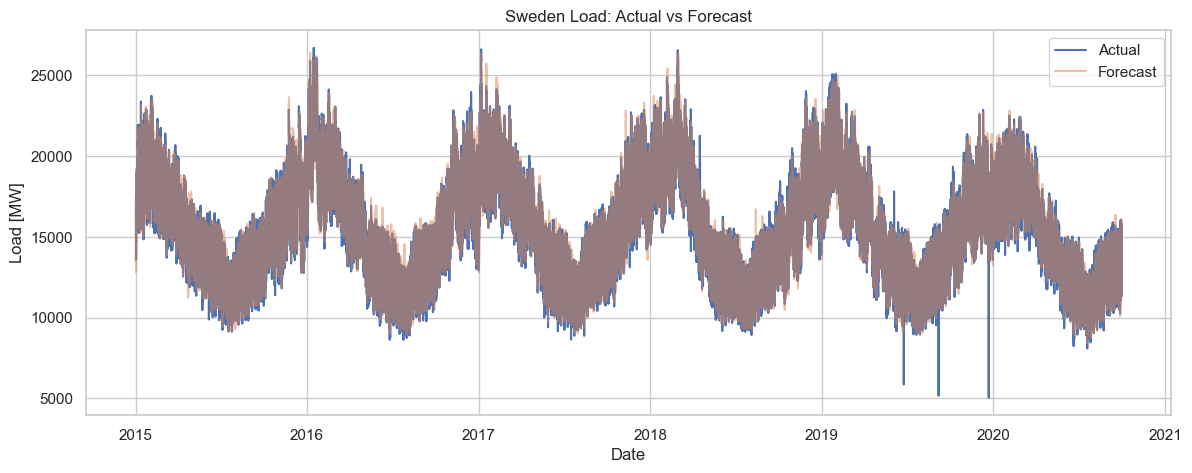

In [72]:
### Plot Actual vs Forecast ###

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df_sweden[target_col], label='Actual')
plt.plot(df_sweden[benchmark_col], label='Forecast', alpha=0.5)
plt.title("Sweden Load: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Load [MW]")
plt.legend()
plt.show()
